Downloading Data from NHTSA

In [2]:
import requests
import pandas as pd
import time

def fetch_suv_data(vehicles, years):
    all_data = []
    
    for year in years:
        for v in vehicles:
            make, model = v['make'], v['model']
            print(f"Fetching: {year} {make} {model}...")
            
            url = f"https://api.nhtsa.gov/complaints/complaintsByVehicle?make={make}&model={model}&modelYear={year}"
            
            try:
                response = requests.get(url)
                if response.status_code == 200:
                    results = response.json().get('results', [])
                    if results:
                        df = pd.DataFrame(results)
                        # 분석을 위해 연도/브랜드/모델 정보 컬럼 고정
                        df['meta_year'] = year
                        df['meta_make'] = make
                        df['meta_model'] = model
                        all_data.append(df)
                
                # API 서버 부하 방지를 위한 짧은 휴식
                time.sleep(0.2) 
            except Exception as e:
                print(f"Error fetching {year} {make} {model}: {e}")

    if all_data:
        return pd.concat(all_data, ignore_index=True)
    return pd.DataFrame()

# 대상 모델 및 연도 설정
target_suvs = [
    {"make": "Toyota", "model": "RAV4"},
    {"make": "Honda", "model": "CR-V"},
    {"make": "Chevrolet", "model": "Equinox"},
    {"make": "Ford", "model": "Explorer"},
    {"make": "Tesla", "model": "Model Y"}
]
target_years = range(2022, 2027) # 2022, 2023, 2024, 2025, 2026

# 실행
df_complaints = fetch_suv_data(target_suvs, target_years)

print(f"\n총 데이터 수: {len(df_complaints)}건")
# 간단한 확인: 모델별/연도별 데이터 분포
print(df_complaints.groupby(['meta_model', 'meta_year']).size().unstack(fill_value=0))



Fetching: 2022 Toyota RAV4...
Fetching: 2022 Honda CR-V...
Fetching: 2022 Chevrolet Equinox...
Fetching: 2022 Ford Explorer...
Fetching: 2022 Tesla Model Y...
Fetching: 2023 Toyota RAV4...
Fetching: 2023 Honda CR-V...
Fetching: 2023 Chevrolet Equinox...
Fetching: 2023 Ford Explorer...
Fetching: 2023 Tesla Model Y...
Fetching: 2024 Toyota RAV4...
Fetching: 2024 Honda CR-V...
Fetching: 2024 Chevrolet Equinox...
Fetching: 2024 Ford Explorer...
Fetching: 2024 Tesla Model Y...
Fetching: 2025 Toyota RAV4...
Fetching: 2025 Honda CR-V...
Fetching: 2025 Chevrolet Equinox...
Fetching: 2025 Ford Explorer...
Fetching: 2025 Tesla Model Y...
Fetching: 2026 Toyota RAV4...
Fetching: 2026 Honda CR-V...
Fetching: 2026 Chevrolet Equinox...
Fetching: 2026 Ford Explorer...
Fetching: 2026 Tesla Model Y...

총 데이터 수: 2969건
meta_year   2022  2023  2024  2025  2026
meta_model                              
CR-V         197   495   357   198    64
Equinox      145    78    55   181    34
Explorer     226    89   

Conducting EDA - 1. Checking Meta data
All columns, number of rows and Null counts, Datatype are summarized

In [4]:
df_complaints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2969 entries, 0 to 2968
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   odiNumber           2969 non-null   int64 
 1   manufacturer        2969 non-null   object
 2   crash               2969 non-null   bool  
 3   fire                2969 non-null   bool  
 4   numberOfInjuries    2969 non-null   int64 
 5   numberOfDeaths      2969 non-null   int64 
 6   dateOfIncident      2969 non-null   object
 7   dateComplaintFiled  2969 non-null   object
 8   vin                 2956 non-null   object
 9   components          2969 non-null   object
 10  summary             2969 non-null   object
 11  products            2969 non-null   object
 12  meta_year           2969 non-null   int64 
 13  meta_make           2969 non-null   object
 14  meta_model          2969 non-null   object
dtypes: bool(2), int64(4), object(9)
memory usage: 307.5+ KB


Noticed that some of the VINs are null :  vin                 2956 non-null   object
13 VIN info are missing

EDA - 2. Checking the nulls (by columns)

In [5]:
# 컬럼별 빈 값의 개수 확인
print("--- 결측치 확인 ---")
print(df_complaints.isnull().sum())

--- 결측치 확인 ---
odiNumber              0
manufacturer           0
crash                  0
fire                   0
numberOfInjuries       0
numberOfDeaths         0
dateOfIncident         0
dateComplaintFiled     0
vin                   13
components             0
summary                0
products               0
meta_year              0
meta_make              0
meta_model             0
dtype: int64


EDA 3. Checking out the outstanding/weird one

In [7]:
# 1. 숫자형 데이터 요약 (통계치)
print(df_complaints.describe())

# 2. 범주형 데이터 확인 (중복 없는 값 목록)
print("--- 수집된 브랜드 목록 ---")
print(df_complaints['meta_make'].unique())

print("--- 부품 카테고리 종류 ---")
print(df_complaints['components'].unique()[:10]) # 너무 많을 수 있으니 10개만

          odiNumber  numberOfInjuries  numberOfDeaths    meta_year
count  2.969000e+03       2969.000000     2969.000000  2969.000000
mean   1.163884e+07          0.059953        0.001010  2023.686763
std    6.879280e+04          0.325949        0.041032     1.315813
min    1.145406e+07          0.000000        0.000000  2022.000000
25%    1.158068e+07          0.000000        0.000000  2023.000000
50%    1.164803e+07          0.000000        0.000000  2024.000000
75%    1.170022e+07          0.000000        0.000000  2025.000000
max    1.173496e+07          4.000000        2.000000  2026.000000
--- 수집된 브랜드 목록 ---
['Toyota' 'Honda' 'Chevrolet' 'Ford' 'Tesla']
--- 부품 카테고리 종류 ---
['STEERING' 'ELECTRICAL SYSTEM' 'UNKNOWN OR OTHER'
 'ELECTRICAL SYSTEM,STRUCTURE,UNKNOWN OR OTHER'
 'STEERING,ELECTRICAL SYSTEM,ENGINE' 'AIR BAGS,WHEELS,ENGINE'
 'ELECTRICAL SYSTEM,ENGINE,FUEL/PROPULSION SYSTEM'
 'POWER TRAIN,VEHICLE SPEED CONTROL,UNKNOWN OR OTHER' 'STRUCTURE' 'WHEELS']


EDA 4: Few Example Check - Randomly sampled 5 data

In [9]:
# 무작위로 5행 추출해서 내용 확인
print(df_complaints[['meta_model', 'components', 'summary']].sample(5))

     meta_model                                         components  \
839        CR-V                  AIR BAGS,STRUCTURE,SERVICE BRAKES   
1539       RAV4                 STEERING,SEAT BELTS,SERVICE BRAKES   
2916    Model Y                             LATCHES/LOCKS/LINKAGES   
2581    Model Y  VEHICLE SPEED CONTROL,FORWARD COLLISION AVOIDANCE   
1242       CR-V         SERVICE BRAKES,FORWARD COLLISION AVOIDANCE   

                                                summary  
839                                          no problem  
1539  Brakes failed to respond wheels locked and ste...  
2916  What happened：While driving at 20 mph on [XXX]...  
2581  Tesla Supervised Self Driving (FSSD) update 14...  
1242  I was driving in the left lane of a two lane s...  


component가 얼마나 많이 있는지, 리스트랑 얼마나 많이 등장하는지 빈도수를 체크해보는 방법:

In [10]:
# 1. 고유한 부품 이름 목록만 보기 (리스트 형태)
distinct_components = df_complaints['components'].unique()
print(f"전체 고유 부품 수: {len(distinct_components)}개")
print(distinct_components)

# 2. 어떤 부품이 가장 많이 나오는지 빈도수와 함께 보기 (추천)
# SQL의 GROUP BY + COUNT 느낌입니다.
component_counts = df_complaints['components'].value_counts()
print("\n--- 부품별 출현 빈도 상위 20개 ---")
print(component_counts.head(20))

전체 고유 부품 수: 306개
['STEERING' 'ELECTRICAL SYSTEM' 'UNKNOWN OR OTHER'
 'ELECTRICAL SYSTEM,STRUCTURE,UNKNOWN OR OTHER'
 'STEERING,ELECTRICAL SYSTEM,ENGINE' 'AIR BAGS,WHEELS,ENGINE'
 'ELECTRICAL SYSTEM,ENGINE,FUEL/PROPULSION SYSTEM'
 'POWER TRAIN,VEHICLE SPEED CONTROL,UNKNOWN OR OTHER' 'STRUCTURE' 'WHEELS'
 'SEAT BELTS' 'STRUCTURE,UNKNOWN OR OTHER'
 'ELECTRICAL SYSTEM,UNKNOWN OR OTHER,ENGINE'
 'AIR BAGS,SEAT BELTS,FORWARD COLLISION AVOIDANCE' 'AIR BAGS'
 'FORWARD COLLISION AVOIDANCE'
 'UNKNOWN OR OTHER,FORWARD COLLISION AVOIDANCE'
 'STEERING,ELECTRICAL SYSTEM' 'POWER TRAIN,VEHICLE SPEED CONTROL' 'ENGINE'
 'STEERING,ENGINE' 'AIR BAGS,SEAT BELTS' 'ELECTRICAL SYSTEM,ENGINE'
 'STRUCTURE,UNKNOWN OR OTHER,VISIBILITY/WIPER'
 'POWER TRAIN,ELECTRICAL SYSTEM,ENGINE' 'SERVICE BRAKES'
 'UNKNOWN OR OTHER,ENGINE'
 'ELECTRICAL SYSTEM,SERVICE BRAKES,FORWARD COLLISION AVOIDANCE'
 'ENGINE,FUEL/PROPULSION SYSTEM' 'LANE DEPARTURE'
 'ELECTRICAL SYSTEM,UNKNOWN OR OTHER' 'TIRES' 'SUSPENSION'
 'AIR BAGS,STRUCTURE

키워드 그룹화 전략 - 탑20개의 컴포넌트들을 키워드로 분리해 대그룹으로 나누기. 

In [12]:
def finalize_categorization(x):
    x = str(x).upper()
    
    # 1. 안전 및 주행 보조 (최근 이슈가 많은 ADAS)
    if any(k in x for k in ['COLLISION', 'LANE DEPARTURE', 'BACK OVER', 'SPEED CONTROL']):
        return 'Driving Assist (ADAS)'
    
    # 2. 조향 (가장 많은 데이터)
    if 'STEERING' in x:
        return 'Steering & Handling'
    
    # 3. 엔진 및 구동계
    if any(k in x for k in ['ENGINE', 'POWER TRAIN', 'FUEL']):
        return 'Engine & Powertrain'
    
    # 4. 제동 및 안전
    if any(k in x for k in ['BRAKES', 'AIR BAGS']):
        return 'Brakes & Safety'
    
    # 5. 전기 장치
    if 'ELECTRICAL' in x:
        return 'Electrical & IT'
    
    # 6. 외장 및 시야
    if any(k in x for k in ['VISIBILITY', 'WIPER', 'LIGHTING', 'STRUCTURE']):
        return 'Exterior & Visibility'
    
    return 'Others'

# 새로운 컬럼에 적용
df_complaints['clean_category'] = df_complaints['components'].apply(finalize_categorization)

# 결과 확인
print(df_complaints['clean_category'].value_counts())

clean_category
Steering & Handling      665
Driving Assist (ADAS)    599
Engine & Powertrain      549
Others                   478
Exterior & Visibility    352
Electrical & IT          182
Brakes & Safety          144
Name: count, dtype: int64


이제 모델별로 적용해보자.

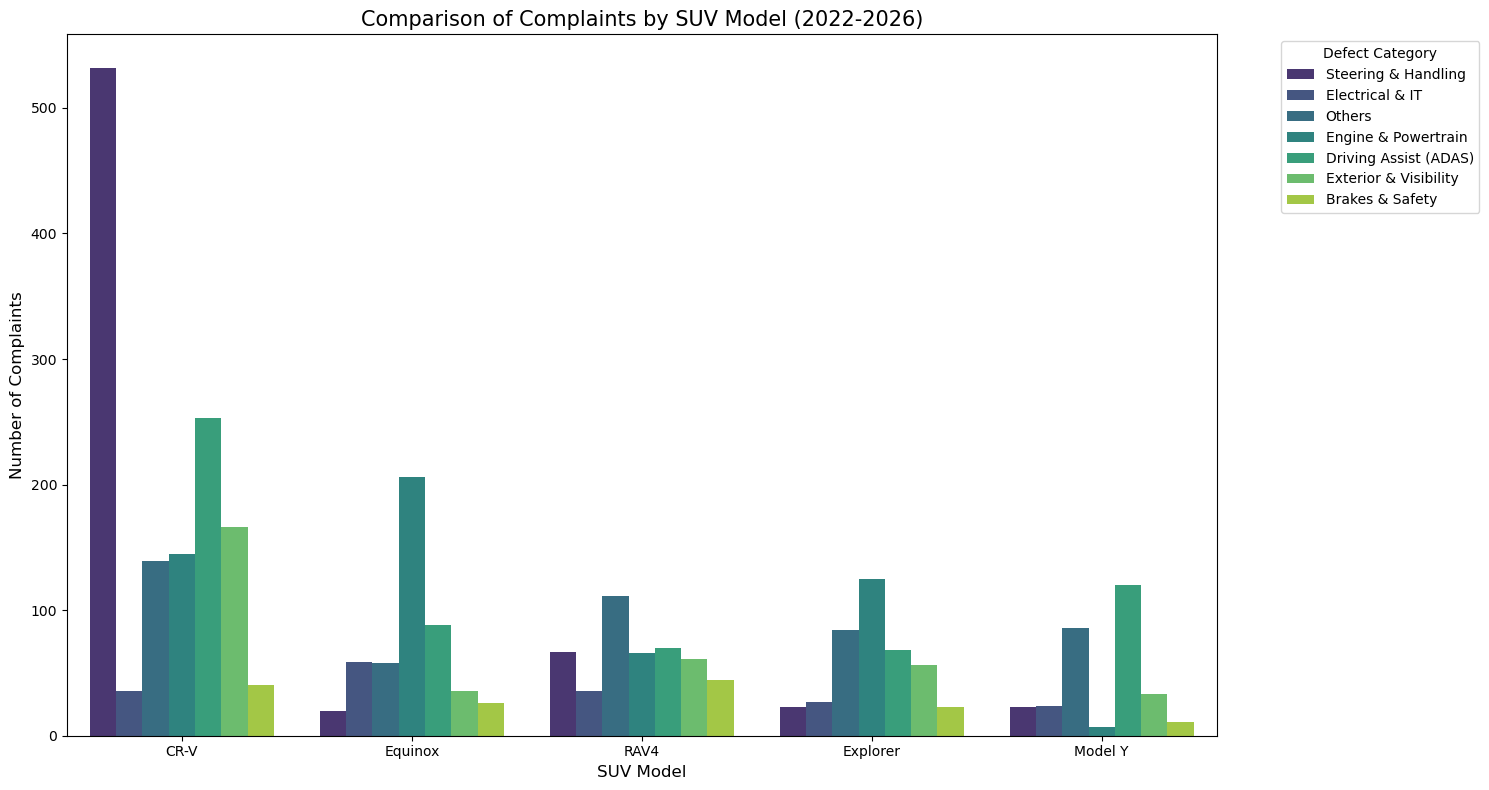

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 모델별로 어떤 카테고리의 결함이 많은지 비중 확인
plt.figure(figsize=(15, 8))
sns.countplot(data=df_complaints, x='meta_model', hue='clean_category', 
              palette='viridis', order=df_complaints['meta_model'].value_counts().index)

plt.title('Comparison of Complaints by SUV Model (2022-2026)', fontsize=15)
plt.xlabel('SUV Model', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.legend(title='Defect Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()